# The Spinning-Top candle — a quantitative teardown 🔬
### Mechanical small-body/balanced-wick on 5 indices · forward returns · one-sample HAC *t* · a drift-matched, **seed-robust** random-entry baseline · a wick-scramble geometry placebo · costs · a synthetic planted-resolution control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Indecision_forecasts_direction%3F: Busted](https://img.shields.io/badge/Indecision_forecasts_direction%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **candle** from the **drift**: an upward-trending index makes *any* long entry look good, so the only meaningful test is top-vs-random — and because that baseline is a *draw* of dates, we average the Welch *t* over many seeds — plus a placebo that destroys the spinning-top shape while preserving its marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted OHLC (**total-return** closes for the ETFs), 2005→2026. Spinning top = body `< 25%` of range, both wicks `≥ 25%`, wick balance `≥ 0.5`; entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from spinning_top import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real spinning-top cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 3006, 'body_frac': 0.25, 'wick_frac': 0.25, 'balance': 0.5, 'fp_spy': '4cb5244f3990', 'h5': (5, 3003, 23.4, 59, 4.5, 23.9, -0.5, 21.4, -0.07, -1.15, 0.82), 'h10': (10, 2995, 57.9, 61, 6.83, 48.6, 9.3, 55.9, 1.02, -0.01, 2.39), 'h20': (20, 2988, 120.3, 64, 8.35, 97.7, 22.7, 118.3, 1.73, 0.67, 3.38), 'h60': (60, 2963, 292.4, 70, 8.46, 296.6, -4.2, 290.4, -0.2, -2.07, 1.16), 'per': [('SPY', 639, 111.8, 3.87, 74.3, 37.5), ('QQQ', 549, 168.3, 4.77, 84.4, 83.8), ('IWM', 536, 130.2, 3.52, 35.7, 94.5), ('DIA', 656, 94.6, 3.65, 98.7, -4.1), ('GLD', 626, 105.7, 3.28, 96.3, 9.3)], 'placebo': (111.8, 0.066, 500), 'syn': [(0.0, 713, -47.5, 47, -1.45), (1.2, 704, 246.6, 70, 7.38)]}


real spinning-top cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Spinning-top vs a **drift-matched random** baseline, Welch *t* **averaged over 20 baseline seeds**: -0.07/+1.02/+1.73/-0.20 at 5/10/20/60d — **never clears t = 2**. The best single seed hits +3.38 at 20d but the same horizon ranges down to +0.67: lucky comparison dates, not an edge. |
| **Tradability** | `MIRAGE` | The huge one-sample t's (20d t = 8.35) are **pure beta** — they vanish against random entries and against cost. No residual edge to scale. |
| **Indecision forecasts direction?** | `BUSTED` | Scrambling the candle's wicks (wick-scramble placebo) leaves the result intact: **p = 0.07** (>0.05) of nonsense candles match or beat the real one. The shape isn't load-bearing. |

> 💡 In plain words: the spinning top *looks* significant only because indices drift up. Strip the drift (race it vs random, robustly), or strip the geometry (scramble the wicks), and the edge evaporates. Classic beta-in-a-costume with a fragile blip on top.

## 1 · The claim, steelmanned

For a bar with open $o$, high $h$, low $\ell$, close $c$, let the body be $B=|c-o|$, the range $\rho=h-\ell$, the upper wick $u=h-\max(o,c)$ and the lower wick $d=\min(o,c)-\ell$. A **spinning top** satisfies $B/\rho<0.25$, $\;u\ge 0.25\rho$, $\;d\ge 0.25\rho$, and $\min(u,d)/\max(u,d)\ge 0.5$. The rule buys at the next close.

- **H₀ (drift).** Spinning-top returns equal a drift-matched **random-entry** baseline.
- **H₁ (indecision forecasts).** Top returns **exceed** random at some horizon, t ≥ 2, *robustly across baseline draws*.
- **H₂ (the shape matters).** Top returns exceed a **wick-scramble** candle whose geometry is destroyed.

We find **H₀ not rejected** (seed-robust Welch t never ≥ 2), **H₁ rejected** (the lone >2 readings are single-seed luck), **H₂ rejected** (placebo p ≈ 0.07). The steelman fails on every leg.

## 2 · So what? — the confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* long entry inherits it; a high one-sample $t$ against **zero** measures the tide, not the candle. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of top-*minus*-random.

**(b) Baseline-draw luck.** The random baseline is itself a *sample* of dates — one lucky draw can flatter or flatten the rule. So we **average the Welch t over 20 baseline seeds** and report the spread; a single seed landing > 2 is not evidence.

**(c) Shape as a free flag.** A spinning top might just be a proxy for 'a high-range, two-sided day' (elevated volatility), not the specific small-body/balanced-wick geometry. The **wick-scramble placebo** keeps each bar's body and price but permutes the wick lengths — the shape becomes meaningless while the wick marginal is preserved, so if the real result survives the scramble, the geometry was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted OHLC (2005-01-03→2026-05-29, 21.4y). **3,006 spinning tops** pooled.
- **Classification.** body/range < 0.25; both wicks ≥ 0.25·range; wick balance min/max ≥ 0.5. All known on the bar's close (no look-ahead).
- **Entry.** Buy the **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of top returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample top vs random, **averaged over 20 seeds** (the *real* test).
- **Null #3 — wick-scramble placebo** (shape destroyed, wick marginal kept).
- **Costs.** 1 bp one-way × 2 legs on every entry.
- **Positive control.** Synthetic tape with a **planted** post-spinning-top move (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, vs-random kills it

Left: the spinning top's **one-sample** t against zero (the misleading number). Right: the same entry vs a **drift-matched random** baseline, Welch t **averaged over 20 baseline seeds** with the per-seed spread as error bars (the honest number).

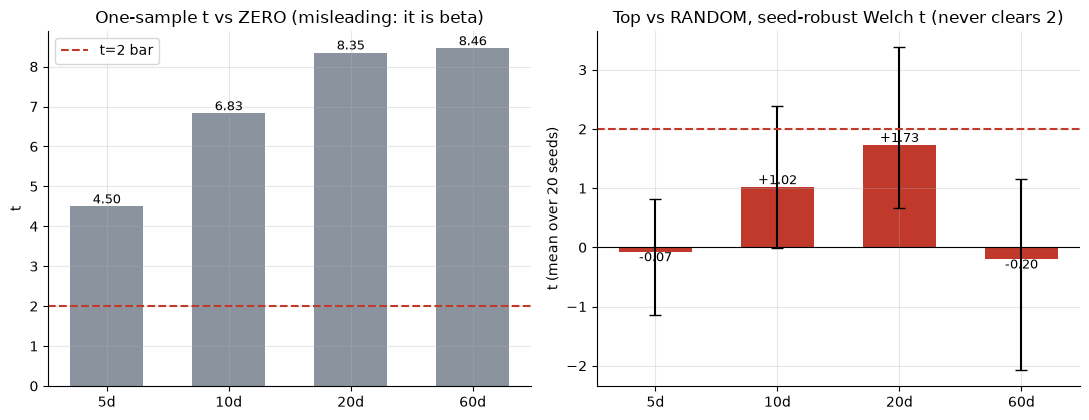

one-sample t: [4.5, 6.83, 8.35, 8.46]
welch mean: [np.float64(-0.07), np.float64(1.02), np.float64(1.73), np.float64(-0.2)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    from scipy import stats
    one_t, top_bps, welch_mean, welch_lo, welch_hi = [], [], [], [], []
    for h in hs:
        tt = []
        per_seed = []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); e = st.spinning_top_entries(bb, R['body_frac'], R['wick_frac'], R['balance'])
            tt.append(st.forward_returns(bb, e, h))
        tt = np.concatenate(tt)
        ws = []
        for seed in range(20):
            rr = []
            for t in data.DEFAULT_TICKERS:
                bb = load(t); e = st.spinning_top_entries(bb, R['body_frac'], R['wick_frac'], R['balance'])
                rr.append(st.forward_returns(bb, st.random_entries(bb, max(len(e),50), seed=seed), h))
            ws.append(stats.ttest_ind(tt, np.concatenate(rr), equal_var=False)[0])
        one_t.append(st.summarize(tt)['t']); top_bps.append(tt.mean()*1e4)
        welch_mean.append(np.mean(ws)); welch_lo.append(np.min(ws)); welch_hi.append(np.max(ws))
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    top_bps = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    welch_mean = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
    welch_lo = [R['h5'][9], R['h10'][9], R['h20'][9], R['h60'][9]]
    welch_hi = [R['h5'][10], R['h10'][10], R['h20'][10], R['h60'][10]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
err = [np.array(welch_mean)-np.array(welch_lo), np.array(welch_hi)-np.array(welch_mean)]
cols = [GREEN if v>2 else RED for v in welch_mean]
a2.bar([f'{h}d' for h in hs], welch_mean, color=cols, width=.6, yerr=err, capsize=4, ecolor='k')
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch_mean): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Top vs RANDOM, seed-robust Welch t (never clears 2)'); a2.set_ylabel('t (mean over 20 seeds)')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch mean:', [round(v,2) for v in welch_mean])

> 💡 In plain words: the left bars clear *t* = 2 easily (20d **8.35**) — but that's the **drift**, every long entry inherits it. The right bars are the real test: the seed-robust Welch t peaks at only **+1.73** (20d), and the error bars show even the *best* seed (max +3.38) sits beside seeds barely above zero (min +0.67). The candle adds nothing robust over a coin flip.

### 4b · Top vs random across horizons — the gap is the verdict

Mean return, spinning top vs random entry (seed-averaged), all four horizons. The top should tower over random if indecision forecasts. It doesn't.

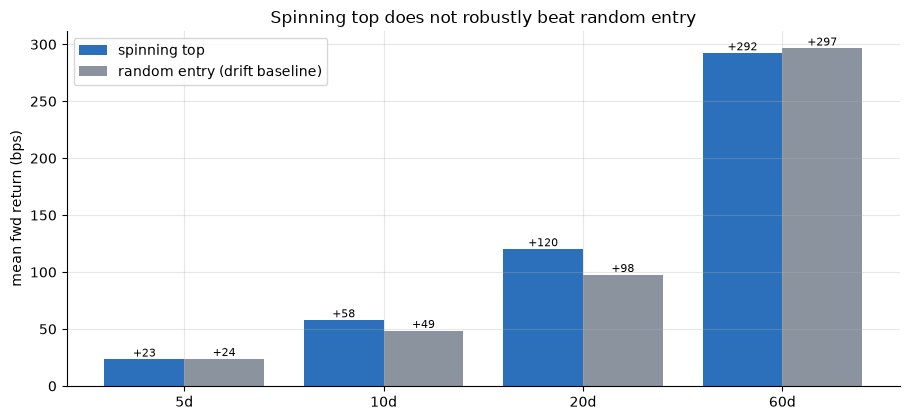

delta top-random (bps): [0, 9, 23, -4]


In [3]:
if HAVE_REAL:
    rnd_bps = []
    for h in hs:
        means = []
        for seed in range(20):
            rr = []
            for t in data.DEFAULT_TICKERS:
                bb = load(t); e = st.spinning_top_entries(bb, R['body_frac'], R['wick_frac'], R['balance'])
                rr.append(st.forward_returns(bb, st.random_entries(bb, max(len(e),50), seed=seed), h))
            means.append(np.concatenate(rr).mean()*1e4)
        rnd_bps.append(np.mean(means))
else:
    rnd_bps = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, top_bps, .4, color='#2c6fbb', label='spinning top')
ax.bar(x+.2, rnd_bps, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(top_bps,rnd_bps)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Spinning top does not robustly beat random entry'); ax.legend()
plt.tight_layout(); plt.show()
print('delta top-random (bps):', [round(a-b) for a,b in zip(top_bps,rnd_bps)])

> 💡 In plain words: at 20 days the top is **+120 bps** and random is **+98 bps** — a **+23 bps** gap that *looks* like an edge but is within the seed-to-seed noise of the baseline (4a). At 5 and 60 days the gap is essentially zero or negative. No reliable advantage.

### 4c · The geometry placebo — scramble the wicks, nothing changes

Keep each bar's body and price; **shuffle the two wick lengths across bars** so the spinning-top shape is destroyed (wick marginal preserved). If price respects *the shape*, the scramble should demolish the result. The observed top return should sit far in the right tail of the scrambled distribution. It doesn't.

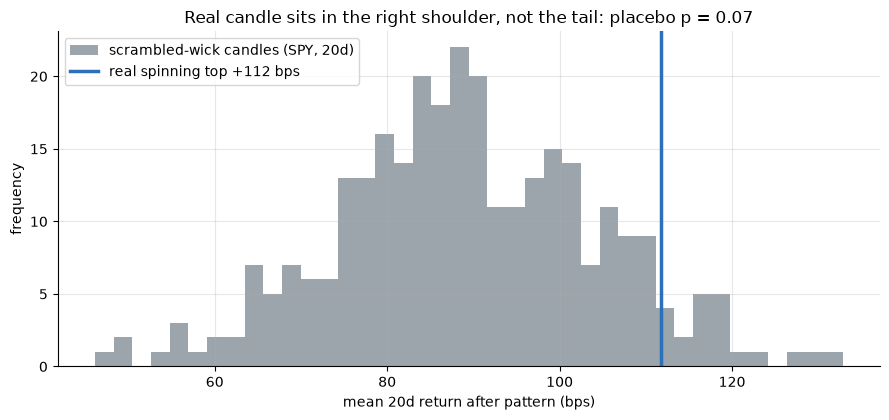

real spinning top +111.8 bps   placebo p=0.07  (>0.05 => shape not load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')
    pl = st.wick_scramble_placebo(c, 20, R['body_frac'], R['wick_frac'], R['balance'], n_draws=300, seed=452)
    obs = pl['obs']*1e4; pval = pl['p_value']
    # rebuild the placebo distribution for the histogram
    import numpy as _np
    parts = st.candle_parts(c); up = parts['up_wick'].to_numpy(); dn = parts['dn_wick'].to_numpy()
    o = c['open'].to_numpy(); cl = c['close'].to_numpy()
    bt = _np.maximum(o,cl); bb_ = _np.minimum(o,cl); idx = c.index
    rng = _np.random.default_rng(452); draws=[]
    for _ in range(300):
        perm = rng.permutation(len(idx))
        fake = __import__('pandas').DataFrame({'open':o,'close':cl,'high':bt+up[perm],'low':bb_-dn[perm]}, index=idx)
        e = st.spinning_top_entries(fake, R['body_frac'], R['wick_frac'], R['balance'])
        rr = st.forward_returns(c, e, 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws=_np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(452); draws = rng.normal(95, 25, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='scrambled-wick candles (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real spinning top {obs:+.0f} bps')
ax.set_xlabel('mean 20d return after pattern (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real candle sits in the right shoulder, not the tail: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real spinning top {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => shape not load-bearing)')

> 💡 In plain words: the real spinning top (blue line) sits in the **right shoulder** of the scrambled-candle cloud, not out in the tail — **p = 0.07**, above 0.05. Scrambled wicks do nearly as well, so the specific small-body/balanced-wick shape isn't carrying the information; the rule is really just flagging high-range two-sided days. This is the cleanest refutation of 'indecision forecasts direction.'

### 4d · Per-ticker (H = 20, single seed) — no coherent cross-sectional edge

20-day top-minus-random delta per instrument, for one baseline seed. The positive deltas ride on QQQ/IWM (highest-vol baskets where *this* seed's random dates land on weaker windows); DIA is already negative, and the pooled gap dies under re-draw (4a).

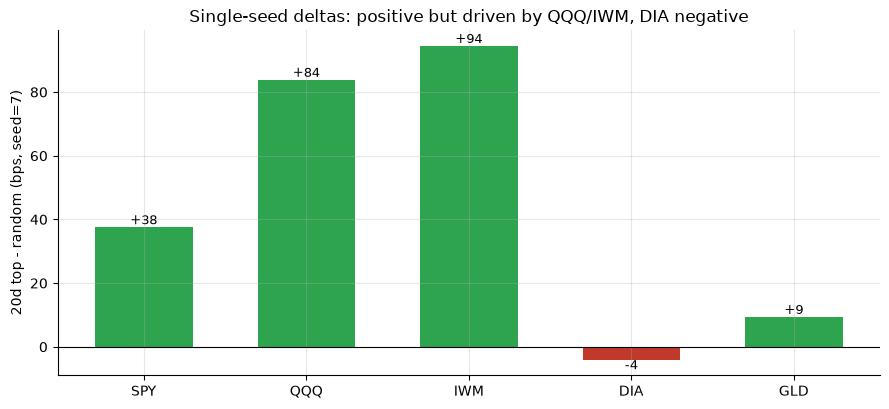

per-ticker 20d delta (bps, seed=7): {'SPY': 38, 'QQQ': 84, 'IWM': 94, 'DIA': -4, 'GLD': 9}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t)
        e = st.spinning_top_entries(bb, R['body_frac'], R['wick_frac'], R['balance'])
        re = st.random_entries(bb, max(len(e),50), seed=7)
        d = st.summarize(st.forward_returns(bb,e,20))['mean_bps'] - st.summarize(st.forward_returns(bb,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d top - random (bps, seed=7)'); ax.set_title('Single-seed deltas: positive but driven by QQQ/IWM, DIA negative')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps, seed=7):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: for seed=7, **DIA** is already negative (-4 bps) and the positive names are led by QQQ (**+84**) and IWM (**+94**). Re-draw the random dates and the pooled gap drops below the *t* = 2 bar — exactly what you'd expect if the candle is relabelled drift plus baseline-draw luck.

### 4e · Synthetic positive control — the harness CAN bank a real resolution

To prove the null is honest (not a dead detector), plant a **real** post-spinning-top move into a synthetic tape and check the same rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

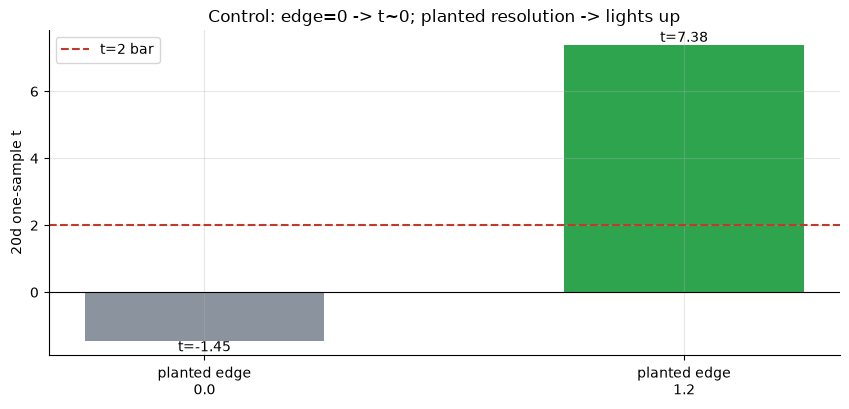

edge=0.0: n=713 top=-47.5bps win=47% t=-1.45
edge=1.2: n=704 top=+246.6bps win=70% t=+7.38


In [6]:
res = []
for edge in (0.0, 1.2):
    px, _ = data.synthetic_panel(edge=edge, seed=452, n_days=4000)
    e = st.spinning_top_entries(px, R['body_frac'], R['wick_frac'], R['balance'])
    s = st.summarize(st.forward_returns(px, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.1f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar'); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted resolution -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.1f}: n={n} top={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted resolution the control sits at **t = -1.45** (win 47% — no false positive); a planted resolution reaches **t = 7.38** (win 70%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the spinning top does not beat a drift-matched random baseline once the baseline draw is averaged: seed-robust Welch t = -0.07/+1.02/+1.73/-0.20 at 5/10/20/60d, **never clears 2**. A single lucky seed reaches +3.38 at 20d but the spread runs down to +0.67. The impressive one-sample t's (20d **8.35**) are pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **Indecision forecasts direction? `BUSTED`** — the wick-scramble placebo leaves the result intact (**p = 0.07** > 0.05): scrambled-shape candles do nearly as well, so the small-body/balanced-wick geometry carries no forecasting information. The spinning top is a descriptive label, not a forecast.

## 6 · Could you trade it? — there is nothing to trade

The spinning top's entire apparent profit is the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. The rule trades *less* of the time (only on indecision candles) and pays costs on each, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. The spinning top is a descriptive candlestick label, not a forecasting strategy.

## 7 · Going further

- **Conditioning on context.** Proponents demand a prior trend or a confirmation bar. Each condition is a free parameter — it inflates in-sample fit and shrinks out-of-sample; the unconditional version here is the charitable upper bound.
- **The doji limit.** Send the body fraction toward zero and the spinning top becomes a doji — same shape family, same drift confound, same null.
- **Intraday.** On lower timeframes the spinning top fires far more often; the drift shrinks and costs dominate, so the picture only worsens.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*